In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Shape of dataset:
(891, 12)

Column names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


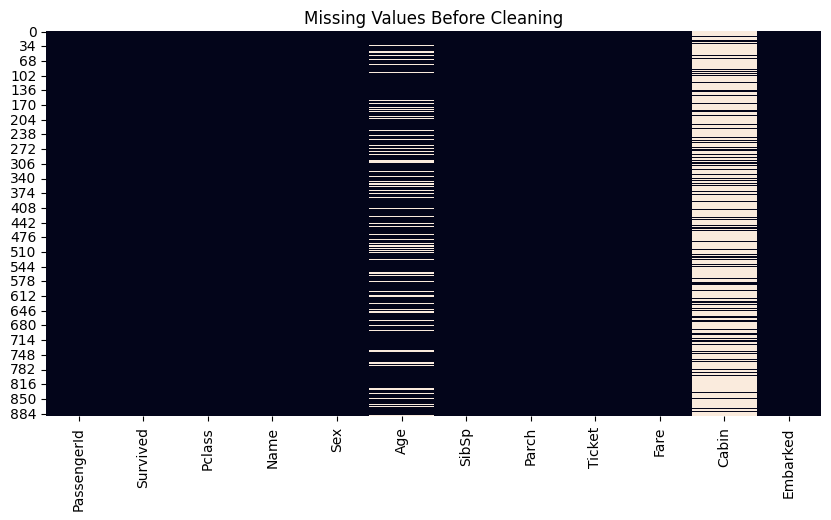

In [7]:
plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Before Cleaning")
plt.show()

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [10]:
df["Age"].isnull().sum()

np.int64(0)

In [11]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [12]:
df["Embarked"].isnull().sum()

np.int64(0)

In [13]:
print("Missing Cabin values:", df["Cabin"].isnull().sum())
print("Total rows:", len(df))

Missing Cabin values: 687
Total rows: 891


In [14]:
df.drop("Cabin", axis=1, inplace=True)

In [15]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [16]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [17]:
df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

In [18]:
print("Remaining columns:")
print(df.columns)

Remaining columns:
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')


In [19]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [20]:
df = pd.get_dummies(
    df,
    columns=["Sex", "Embarked"],
    drop_first=True
)

df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [21]:
bool_columns = df.select_dtypes(include="bool").columns

df[bool_columns] = df[bool_columns].astype(int)

In [22]:
print(df.dtypes)

Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male        int64
Embarked_Q      int64
Embarked_S      int64
dtype: object


In [23]:
drop_first=True

In [24]:
print(df.columns)

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')


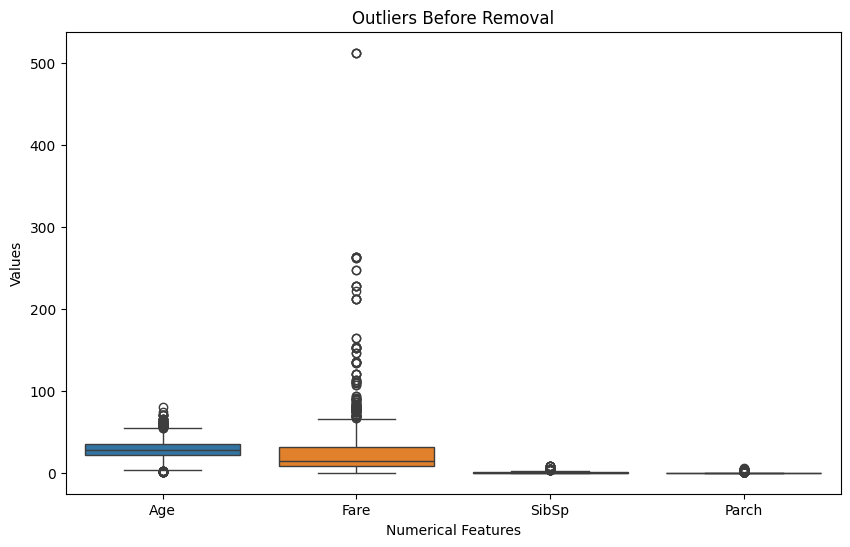

In [25]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[["Age", "Fare", "SibSp", "Parch"]])

plt.title("Outliers Before Removal")
plt.xlabel("Numerical Features")
plt.ylabel("Values")

plt.show()

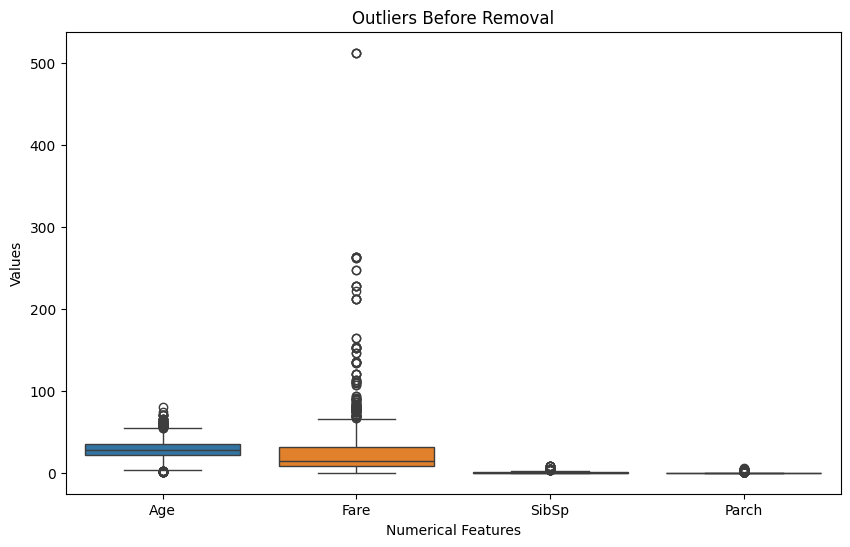

In [26]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[["Age", "Fare", "SibSp", "Parch"]])

plt.title("Outliers Before Removal")
plt.xlabel("Numerical Features")
plt.ylabel("Values")

plt.savefig("outliers_before.png", dpi=300, bbox_inches="tight")

plt.show()

In [27]:
numeric_columns = ["Age", "Fare", "SibSp", "Parch"]

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[column] >= lower_bound) &
        (df[column] <= upper_bound)
    ]

print("Shape after removing outliers:")
print(df.shape)

Shape after removing outliers:
(577, 9)


In [28]:
print("Remaining rows:", len(df))
print("Remaining columns:", len(df.columns))

Remaining rows: 577
Remaining columns: 9


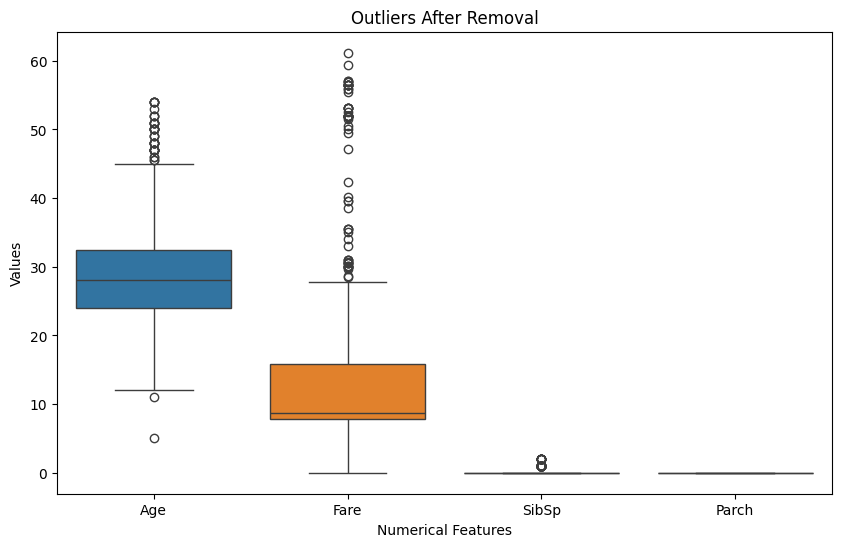

In [29]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[["Age", "Fare", "SibSp", "Parch"]])

plt.title("Outliers After Removal")
plt.xlabel("Numerical Features")
plt.ylabel("Values")

plt.savefig("outliers_after.png", dpi=300, bbox_inches="tight")

plt.show()

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()

In [32]:
numeric_columns = ["Age", "Fare", "SibSp", "Parch"]

df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

In [33]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,-0.854761,1.800735,0.0,-0.609448,1,0,1
2,1,3,-0.386610,-0.448235,0.0,-0.555858,0,0,1
3,1,1,0.666730,1.800735,0.0,3.030715,0,0,1
4,0,3,0.666730,-0.448235,0.0,-0.545934,1,0,1
5,0,3,-0.152535,-0.448235,0.0,-0.513517,1,1,0


In [34]:
print(df[numeric_columns].mean())

Age      1.231443e-17
Fare     3.078608e-17
SibSp    6.157216e-18
Parch    0.000000e+00
dtype: float64


In [35]:
print(df[numeric_columns].std())

Age      1.000868
Fare     1.000868
SibSp    1.000868
Parch    0.000000
dtype: float64


In [36]:
print("Final Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFinal Columns:")
print(df.columns)

print("\nFirst 5 Rows:")
display(df.head())

Final Dataset Shape:
(577, 9)

Missing Values:
Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

Final Columns:
Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

First 5 Rows:


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,-0.854761,1.800735,0.0,-0.609448,1,0,1
2,1,3,-0.386610,-0.448235,0.0,-0.555858,0,0,1
3,1,1,0.666730,1.800735,0.0,3.030715,0,0,1
4,0,3,0.666730,-0.448235,0.0,-0.545934,1,0,1
5,0,3,-0.152535,-0.448235,0.0,-0.513517,1,1,0


In [37]:
df.to_csv("Titanic-Cleaned.csv", index=False)

print("Titanic-Cleaned.csv saved successfully!")

Titanic-Cleaned.csv saved successfully!


In [38]:
import os

print(os.listdir())

['.config', 'Titanic-Cleaned.csv', 'outliers_before.png', 'outliers_after.png', 'sample_data']


In [39]:
from google.colab import files

files.download("Titanic-Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
files.download("outliers_before.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
files.download("outliers_after.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>